# Analisis Lanjutan SSDC 2026: Demand-Supply, Skill Gap, dan Talent Matching

Notebook ini melanjutkan **`Analisis_Awal_Dataset_SSDC_2026.ipynb`**. Notebook
sebelumnya berhenti pada pembersihan data dan eksplorasi *per tabel* (grain
tetap dijaga per tabel, belum ada analisis lintas tabel).

Notebook ini masuk ke tahap berikutnya: membangun **analytical mart** lintas
tabel, lalu menjawab pertanyaan bisnis yang menjadi inti dataset ini —
sebagaimana disebutkan di bagian kesimpulan dokumentasi dataset:

> "Kekuatan dataset ini terletak pada kemampuannya mendukung analisis:
> supply dan demand talent; matching mahasiswa; prioritas request;
> monitoring funnel; placement rate; rejection dan ghosting; follow-up;
> kualitas dan sinkronisasi data."

## Cakupan notebook ini

| # | Bagian | Menjawab Business Task |
|---|---|---|
| 1 | Setup & pembersihan data (ringkas, mengikuti notebook 1) | - |
| 2 | Tiga analytical mart (student readiness, talent request, candidate pipeline) | dasar seluruh BT |
| 3 | Analisis **Demand vs Supply** talent per program studi & waktu | BT-01, BT-03, BT-04 |
| 4 | Analisis **Skill / Tools Gap** | BT-01, BT-06 |
| 5 | **Rule-based talent matching** & validasi terhadap placement historis | BT-01, BT-06 |
| 6 | **Funnel seleksi**, acceptance rate, dan **ghosting** | BT-02, BT-04, BT-05 |
| 7 | **Prioritas talent request** (backlog & request age) | BT-03 |
| 8 | Tindak lanjut kualitas data | BT-08 |
| 9 | Ringkasan insight & rekomendasi dashboard/laporan | seluruh BT |
| 10 | Menyimpan mart & tabel hasil analisis | - |

## Mengapa demand-supply, skill gap, dan matching relevan untuk dataset ini?

Struktur dataset secara eksplisit dirancang mempertemukan dua sisi:
mahasiswa (supply) dan kebutuhan perusahaan (demand), dengan `tools` di
`status_student` dan kebutuhan teknis di `talent_request.deskripsi_requirement`
sebagai jembatan skill. Ketiga jenis analisis ini bukan tambahan opsional,
melainkan **jawaban langsung** atas BT-01 (matching talent) dan pendukung
BT-03/BT-04 (prioritas request dan tingkat keberhasilan). Notebook ini
mengimplementasikannya secara eksploratif; keputusan desain akhir (bobot
skor matching, ambang gap) tetap perlu didiskusikan dengan tim sebelum
dituangkan ke laporan.

## Batasan yang tetap berlaku

- Dataset **tidak memiliki riwayat status per tahap** (hanya `last_update`),
  sehingga durasi *antar tahap* seleksi tidak dapat dihitung persis — hanya
  usia proses sejak pembaruan terakhir.
- Kolom `eligible` tidak ada secara eksplisit; kelayakan dibentuk dari aturan
  (`basic_ready`, mengikuti dokumentasi dataset bagian 7.4).
- Kebutuhan tools pada `talent_request.deskripsi_requirement` berupa teks
  bebas. Ekstraksi tools menggunakan pencocokan kata kunci terhadap kosakata
  tools yang muncul di `status_student.tools` — pendekatan ini heuristik,
  bukan NLP penuh, dan sebaiknya diperiksa manual sebelum dipakai di laporan
  final.
- Sesuai aturan lomba, **tidak ada data eksternal** yang ditambahkan.

## 1. Setup, pembersihan data, dan pemuatan enam tabel

Bagian ini mengulang pembersihan dari notebook 1 secara ringkas agar notebook
ini dapat dijalankan berdiri sendiri. Fungsi pembersihan sengaja dibuat sama
persis dengan notebook 1 agar hasil kedua notebook tetap konsisten.

In [1]:
from pathlib import Path
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Markdown

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

In [2]:
EXPECTED_FILES = {
    "company": "company.csv",
    "talent_request": "talent_request.csv",
    "student_all": "student_all.csv",
    "status_student": "status_student.csv",
    "tracking_company": "tracking_company.csv",
    "tracking_student": "tracking_student.csv",
}

candidate_dirs = [
    Path("Database SSDC 2026 UNZIP"),
    Path("."),
    Path("/mnt/data/Database SSDC 2026 UNZIP"),
    Path("/mnt/data"),
]

DATA_DIR = None
for candidate in candidate_dirs:
    if all((candidate / filename).exists() for filename in EXPECTED_FILES.values()):
        DATA_DIR = candidate.resolve()
        break

if DATA_DIR is None:
    raise FileNotFoundError(
        "Folder data tidak ditemukan. Pastikan keenam CSV berada di folder "
        "'Database SSDC 2026 UNZIP' atau satu folder dengan notebook, "
        "sama seperti pada notebook 1."
    )

print(f"Folder data: {DATA_DIR}")

Folder data: C:\Users\ACER\OneDrive\Dokumen\COMPETITION\SSF_SSDC_2026\Database SSDC 2026 UNZIP


In [3]:
def read_table(path, separator=","):
    return pd.read_csv(
        path,
        sep=separator,
        dtype="string",
        encoding="utf-8-sig",
        low_memory=False,
    )


raw_tables = {
    "company": read_table(DATA_DIR / EXPECTED_FILES["company"]),
    "talent_request": read_table(DATA_DIR / EXPECTED_FILES["talent_request"]),
    "student_all": read_table(DATA_DIR / EXPECTED_FILES["student_all"]),
    "status_student": read_table(
        DATA_DIR / EXPECTED_FILES["status_student"],
        separator=";",
    ),
    "tracking_company": read_table(DATA_DIR / EXPECTED_FILES["tracking_company"]),
    "tracking_student": read_table(DATA_DIR / EXPECTED_FILES["tracking_student"]),
}

print("Enam tabel berhasil dibaca:")
for name, df in raw_tables.items():
    print(f"  {name}: {df.shape[0]:,} baris x {df.shape[1]} kolom")

Enam tabel berhasil dibaca:
  company: 1,500 baris x 9 kolom
  talent_request: 12,000 baris x 19 kolom
  student_all: 25,000 baris x 10 kolom
  status_student: 25,000 baris x 15 kolom
  tracking_company: 12,000 baris x 13 kolom
  tracking_student: 41,600 baris x 11 kolom


In [4]:
def to_snake_case(text):
    text = str(text).strip().lower()
    text = re.sub(r"[^a-z0-9]+", "_", text)
    return text.strip("_")


def clean_base(df):
    result = df.copy()
    result.columns = [to_snake_case(col) for col in result.columns]

    for col in result.columns:
        if pd.api.types.is_string_dtype(result[col]):
            result[col] = (
                result[col]
                .astype("string")
                .str.strip()
                .replace({"": pd.NA, "nan": pd.NA, "None": pd.NA})
            )
    return result


def normalize_phone(series):
    def clean_one(value):
        if pd.isna(value):
            return pd.NA
        digits = re.sub(r"\D", "", str(value))
        if digits.startswith("62"):
            digits = "0" + digits[2:]
        elif digits.startswith("8"):
            digits = "0" + digits
        return digits if digits else pd.NA

    return series.apply(clean_one).astype("string")


def to_numeric_safe(series):
    return pd.to_numeric(series, errors="coerce")


def parse_date(series, date_format):
    return pd.to_datetime(series, format=date_format, errors="coerce")


def split_multivalue(series, separator=","):
    return (
        series.dropna()
        .str.split(separator)
        .explode()
        .str.strip()
        .replace("", pd.NA)
        .dropna()
    )


def parse_indonesian_month(series):
    month_map = {
        "Januari": "01", "Februari": "02", "Maret": "03", "April": "04",
        "Mei": "05", "Juni": "06", "Juli": "07", "Agustus": "08",
        "September": "09", "Oktober": "10", "November": "11", "Desember": "12",
    }
    extracted = series.str.extract(r"(?P<bulan>[A-Za-z]+)\s+(?P<tahun>\d{4})")
    month_number = extracted["bulan"].map(month_map)
    return pd.to_datetime(
        extracted["tahun"] + "-" + month_number + "-01",
        errors="coerce",
    )


def extract_rupiah_amount(series):
    return pd.to_numeric(
        series.str.replace(r"\D", "", regex=True).replace("", pd.NA),
        errors="coerce",
    )


def plot_count_bar(series, title, xlabel="Jumlah", top_n=None, figsize=None):
    counts = series.value_counts(dropna=False)
    if top_n is not None:
        counts = counts.head(top_n)
    counts = counts.sort_values()

    plt.figure(figsize=figsize or (9, max(4, len(counts) * 0.38)))
    counts.plot(kind="barh")
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel("")
    plt.grid(axis="x", alpha=0.25)
    for index, value in enumerate(counts.values):
        plt.text(value, index, f" {value:,.0f}", va="center")
    plt.tight_layout()
    plt.show()


def plot_histogram(series, title, xlabel, bins=20):
    values = series.dropna()
    plt.figure(figsize=(9, 4.8))
    plt.hist(values, bins=bins)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel("Frekuensi")
    plt.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    plt.show()


def plot_time_series(series, title, xlabel="Periode", ylabel="Jumlah"):
    values = series.sort_index()
    plt.figure(figsize=(11, 4.8))
    plt.plot(values.index, values.values, marker="o", linewidth=1.5)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

In [5]:
# COMPANY
company = clean_base(raw_tables["company"])
company["pic_phone"] = normalize_phone(company["pic_phone"])
company["created_at"] = parse_date(company["created_at"], "%Y-%m-%d")
company["registration_year"] = company["created_at"].dt.year.astype("Int64")

# TALENT REQUEST
talent_request = clean_base(raw_tables["talent_request"])
talent_request["no_whatsapp"] = normalize_phone(talent_request["no_whatsapp"])
for col in ["headcount", "minimum_semester"]:
    talent_request[col] = to_numeric_safe(talent_request[col]).astype("Int64")
talent_request["request_date"] = parse_date(talent_request["request_date"], "%Y-%m-%d")
talent_request["request_month"] = (
    talent_request["request_date"].dt.to_period("M").dt.to_timestamp()
)
talent_request["duration_months"] = (
    talent_request["durasi"].str.extract(r"(\d+)", expand=False)
    .pipe(to_numeric_safe).astype("Int64")
)
talent_request["remuneration_amount"] = extract_rupiah_amount(talent_request["renumerasi"])
talent_request["remuneration_type"] = np.select(
    [
        talent_request["renumerasi"].str.contains("Non-Paid", case=False, na=False),
        talent_request["renumerasi"].str.contains("transport", case=False, na=False),
        talent_request["remuneration_amount"].notna(),
    ],
    ["Non-Paid", "Transport Only", "Paid"],
    default="Other",
)
talent_request["required_study_count"] = (
    talent_request["bidang_studi_dibutuhkan"].fillna("").str.split(",").str.len()
)

# STUDENT ALL
student_all = clean_base(raw_tables["student_all"])
student_all["nim"] = student_all["nim"].astype("string")
student_all["hp"] = normalize_phone(student_all["hp"])
student_all["semester"] = to_numeric_safe(student_all["semester"]).astype("Int64")
student_all["entry_date"] = parse_indonesian_month(student_all["bulan_masuk"])
student_all["entry_year"] = student_all["entry_date"].dt.year.astype("Int64")

# STATUS STUDENT
status_student = clean_base(raw_tables["status_student"])
status_student["nim"] = status_student["nim"].astype("string")
status_student["no_whatsapp"] = normalize_phone(status_student["no_whatsapp"])
status_student["semester"] = to_numeric_safe(status_student["semester"]).astype("Int64")
status_student["ipk"] = to_numeric_safe(status_student["ipk"])
status_student["sync_date"] = parse_date(status_student["sync_date"], "%d/%m/%Y")
status_student["tools_count"] = (
    status_student["tools"].fillna("").str.split(",").str.len()
)
status_student["basic_ready"] = (
    status_student["status"].eq("Active")
    & status_student["ketersediaan"].eq("Available")
    & status_student["cv"].eq("Ada")
)
status_reference_date = status_student["sync_date"].max()
status_student["days_since_sync"] = (
    status_reference_date - status_student["sync_date"]
).dt.days

# TRACKING COMPANY
tracking_company = clean_base(raw_tables["tracking_company"])
for col in ["jumlah_permintaan", "jumlah_dikirimkan"]:
    tracking_company[col] = to_numeric_safe(tracking_company[col]).astype("Int64")
tracking_company["request_date"] = parse_date(tracking_company["request_date"], "%d/%m/%Y")
tracking_company["send_date"] = parse_date(tracking_company["send_date"], "%d/%m/%Y")
tracking_company["days_to_send"] = (
    tracking_company["send_date"] - tracking_company["request_date"]
).dt.days
tracking_company["candidate_gap"] = (
    tracking_company["jumlah_dikirimkan"] - tracking_company["jumlah_permintaan"]
)
tracking_company["coverage_ratio"] = (
    tracking_company["jumlah_dikirimkan"]
    / tracking_company["jumlah_permintaan"].replace(0, np.nan)
)
tracking_company["list_nim_count"] = (
    tracking_company["list_nim"].fillna("")
    .apply(lambda value: len([n.strip() for n in value.split(",") if n.strip()]))
)

# TRACKING STUDENT
tracking_student = clean_base(raw_tables["tracking_student"])
tracking_student["nim"] = tracking_student["nim"].astype("string")
tracking_student["internship_semester"] = to_numeric_safe(
    tracking_student["internship_semester"]
).astype("Int64")
tracking_student["last_update"] = parse_date(tracking_student["last_update"], "%Y-%m-%d")

tracking_student["outcome_group"] = "On Progress"
placement_mask = (
    tracking_student["rejection"].eq("Placement")
    | tracking_student["progress_student"].eq("Placement")
)
ghosting_mask = (
    tracking_student["rejection"].eq("Ghosting")
    | tracking_student["progress_student"].eq("Ghosting")
)
rejected_mask = (
    tracking_student["rejection"].str.startswith("Rejection", na=False)
    | tracking_student["progress_student"].eq("Rejected")
)
finish_unclear_mask = (
    tracking_student["progress_student"].eq("Finish")
    & tracking_student["rejection"].eq("On Progress")
)
tracking_student.loc[placement_mask, "outcome_group"] = "Placement"
tracking_student.loc[ghosting_mask, "outcome_group"] = "Ghosting"
tracking_student.loc[rejected_mask, "outcome_group"] = "Rejected"
tracking_student.loc[finish_unclear_mask, "outcome_group"] = "Finish - Unclear"

tracking_reference_date = tracking_student["last_update"].max()
tracking_student["days_since_update"] = (
    tracking_reference_date - tracking_student["last_update"]
).dt.days

clean_tables = {
    "company": company,
    "talent_request": talent_request,
    "student_all": student_all,
    "status_student": status_student,
    "tracking_company": tracking_company,
    "tracking_student": tracking_student,
}

print("Pembersihan selesai. Tabel siap dipakai untuk membangun mart.")

Pembersihan selesai. Tabel siap dipakai untuk membangun mart.


## 2. Membangun tiga analytical mart

Mengikuti rekomendasi pada notebook 1 (bagian 16) dan struktur analisis yang
disarankan pada dokumentasi dataset (bagian 12), tiga mart dibangun dengan
grain yang **eksplisit dan tetap dijaga**:

1. **`student_readiness_mart`** — 1 baris = 1 mahasiswa.
2. **`talent_request_mart`** — 1 baris = 1 talent request (batch tracking
   diagregasikan lebih dulu sebelum join, agar `headcount` tidak berganda).
3. **`candidate_pipeline_mart`** — 1 baris = 1 mahasiswa x 1 proses seleksi.

Satu tanggal referensi dipakai untuk seluruh perhitungan usia/backlog lintas
tabel agar konsisten.

In [6]:
REFERENCE_DATE = max(
    talent_request["request_date"].max(),
    tracking_company["request_date"].max(),
    tracking_company["send_date"].max(),
    tracking_student["last_update"].max(),
    status_student["sync_date"].max(),
)
print(f"Tanggal referensi analisis (data terbaru yang tercatat): {REFERENCE_DATE.date()}")

Tanggal referensi analisis (data terbaru yang tercatat): 2025-05-17


### 2.1 `student_readiness_mart`

`student_all` (identitas, statis) di-*left join* dengan `status_student`
(kondisi terkini). Mahasiswa tanpa baris `status_student` berarti belum
tersinkron — ditandai eksplisit, bukan dianggap otomatis tidak siap.

In [31]:
status_cols = [
    "nim", "cv", "portofolio", "ipk", "status", "domisili", "ketersediaan",
    "tools", "tools_count", "basic_ready", "sync_date", "days_since_sync",
]

student_readiness_mart = student_all.merge(
    status_student[status_cols],
    on="nim",
    how="left",
    validate="one_to_one",
)

student_readiness_mart["has_status_record"] = student_readiness_mart["status"].notna()
student_readiness_mart["basic_ready"] = student_readiness_mart["basic_ready"].fillna(False)

# jumlah placement & proses aktif per mahasiswa (dihitung nanti setelah
# candidate_pipeline_mart terbentuk, lihat 2.3)

print(f"student_readiness_mart: {student_readiness_mart.shape[0]:,} baris (grain = 1 mahasiswa)")
print(
    f"Mahasiswa tanpa status_student (belum tersinkron): "
    f"{(~student_readiness_mart['has_status_record']).sum():,}"
)
display(student_readiness_mart.head(10))

student_readiness_mart: 25,000 baris (grain = 1 mahasiswa)
Mahasiswa tanpa status_student (belum tersinkron): 0


,nim,nama,program_studi,semester,hp,email_pribadi,email_kampus,bidang_minat,jenis_penempatan_diminati,bulan_masuk,entry_date,entry_year,cv,portofolio,ipk,status,domisili,ketersediaan,tools,tools_count,basic_ready,sync_date,days_since_sync,has_status_record
0,20230001,Aditya Utami,Desain Komunikasi Visual,2,081695318500,aditya.utami@gmail.com,20230001@student.uns.ac.id,Desain,Magang,Februari 2023,2023-02-01,2023,Tidak Ada,Ada,3.52,Active,Surakarta,Tidak Aktif,"Adobe After Effects, Adobe Photoshop, Adobe Il...",5,False,2024-11-24,68,True
1,20210002,Fajar Rahmawati,Pendidikan Teknik Informatika,5,082104810930,fajar.rahmawati@gmail.com,20210002@student.uns.ac.id,Teknologi,Full-time,September 2021,2021-09-01,2021,Ada,Ada,3.91,Active,Boyolali,Placed,"Python, Scratch",2,False,2023-09-26,493,True
2,20230003,Tika Adriansyah,Teknik Industri,2,081679739824,tika.adriansyah@gmail.com,20230003@student.uns.ac.id,Teknologi,Magang,September 2023,2023-09-01,2023,Ada,Tidak Ada,3.53,Cuti,Surakarta,Tidak Aktif,"Arena Simulation, Minitab, SAP",3,False,2024-06-03,242,True
3,20230004,Dinda Ningsih,Teknik Elektro,3,083827238264,dinda.ningsih@gmail.com,20230004@student.uns.ac.id,Teknologi,Full-time,September 2023,2023-09-01,2023,Ada,Ada,3.65,Active,Surakarta,Placed,"C/C++, Arduino, MATLAB, Eagle PCB, Verilog",5,False,2024-07-18,197,True
4,20230005,Isna Hidayat,Akuntansi,2,085368815590,isna.hidayat@gmail.com,20230005@student.uns.ac.id,Bisnis,Part-time,Maret 2023,2023-03-01,2023,Ada,Ada,3.76,Lulus,Yogyakarta,Tidak Aktif,"MYOB, SAP, Excel, Power BI, SQL",5,False,2024-05-17,259,True
5,20210006,Nanda Prasetya,Statistika,7,083876150488,nanda.prasetya@gmail.com,20210006@student.uns.ac.id,Sains,Magang,September 2021,2021-09-01,2021,Ada,Tidak Ada,3.81,Active,Jakarta,Tidak Aktif,"Excel, Power BI",2,False,2025-01-17,14,True
6,20210007,Farel Handayani,Ilmu Hukum,7,085764035076,farel.handayani@gmail.com,20210007@student.uns.ac.id,Sosial,Part-time,Agustus 2021,2021-08-01,2021,Ada,Ada,3.45,Active,Surakarta,Placed,"Microsoft Office, Mendeley, Westlaw, LexisNexi...",5,False,2023-03-30,673,True
7,20220008,Wulan Hakim,Ilmu Komunikasi,3,081308227754,wulan.hakim@gmail.com,20220008@student.uns.ac.id,Sosial,Magang,September 2022,2022-09-01,2022,Ada,Ada,3.20,Cuti,Yogyakarta,Tidak Aktif,"WordPress, Canva",2,False,2023-02-25,706,True
8,20210009,Dinda Firdaus,Agroteknologi,6,085612387249,dinda.firdaus@gmail.com,20210009@student.uns.ac.id,Sains,Magang,Agustus 2021,2021-08-01,2021,Ada,Ada,2.93,Active,Depok,Placed,"R, SPSS",2,False,2024-04-04,302,True
9,20230010,Hanif Anggraeni,Manajemen,2,081655948496,hanif.anggraeni@gmail.com,20230010@student.uns.ac.id,Bisnis,Part-time,Agustus 2023,2023-08-01,2023,Ada,Ada,2.69,Active,Surakarta,Placed,"Excel, Canva, Google Analytics, SQL, SAP",5,False,2025-01-13,18,True


### 2.2 `talent_request_mart`

`tracking_company` diagregasikan ke grain **1 talent request** terlebih
dahulu (satu request bisa memiliki lebih dari satu batch pengiriman),
baru di-join ke `talent_request` dan `company`. Jumlah placement per request
dihitung dari `tracking_student` melalui `tracking_company`, bukan dengan
menjumlahkan `headcount` setelah join penuh — supaya angka tidak berganda.

In [32]:
tracking_company_agg = (
    tracking_company.groupby("id_talent_req")
    .agg(
        jumlah_batch=("id_tracking_company", "nunique"),
        total_dikirimkan=("jumlah_dikirimkan", "sum"),
        tanggal_kirim_pertama=("send_date", "min"),
        tanggal_kirim_terakhir=("send_date", "max"),
        progress_terakhir=("progress", "last"),
    )
    .reset_index()
)

# placement count per request: tracking_student -> tracking_company -> id_talent_req
tracking_student_with_request = tracking_student.merge(
    tracking_company[["id_tracking_company", "id_talent_req"]],
    on="id_tracking_company",
    how="left",
)

placement_per_request = (
    tracking_student_with_request[
        tracking_student_with_request["outcome_group"].eq("Placement")
    ]
    .groupby("id_talent_req")
    .size()
    .rename("jumlah_placement")
)

candidate_count_per_request = (
    tracking_student_with_request.groupby("id_talent_req")
    .size()
    .rename("jumlah_kandidat_diproses")
)

talent_request_mart = (
    talent_request.merge(
        company[["id_company", "company_name", "company_type", "industry_sector", "kota", "skala_perusahaan"]],
        on="id_company",
        how="left",
        suffixes=("", "_master"),
    )
    .merge(tracking_company_agg, on="id_talent_req", how="left")
    .merge(placement_per_request, on="id_talent_req", how="left")
    .merge(candidate_count_per_request, on="id_talent_req", how="left")
)

for col in ["jumlah_batch", "total_dikirimkan", "jumlah_placement", "jumlah_kandidat_diproses"]:
    talent_request_mart[col] = talent_request_mart[col].fillna(0).astype("Int64")

talent_request_mart["request_age_days"] = (
    REFERENCE_DATE - talent_request_mart["request_date"]
).dt.days
talent_request_mart["coverage_ratio_request"] = (
    talent_request_mart["total_dikirimkan"] / talent_request_mart["headcount"].replace(0, np.nan)
)
talent_request_mart["fill_rate"] = (
    talent_request_mart["jumlah_placement"] / talent_request_mart["headcount"].replace(0, np.nan)
).clip(upper=1)
talent_request_mart["backlog_headcount"] = (
    talent_request_mart["headcount"] - talent_request_mart["jumlah_placement"]
).clip(lower=0)
talent_request_mart["is_open"] = talent_request_mart["backlog_headcount"] > 0

print(f"talent_request_mart: {talent_request_mart.shape[0]:,} baris (grain = 1 talent request)")
display(talent_request_mart.head(10))

talent_request_mart: 12,000 baris (grain = 1 talent request)


,id_talent_req,id_company,nama_perusahaan,alamat_kantor,industri_sektor,nama_pic,no_whatsapp,nama_posisi,jenis_penempatan,headcount,bidang_studi_dibutuhkan,minimum_semester,deskripsi_requirement,working_arrangement,working_arrangement_detail,durasi,renumerasi,request_date,sumber_baris_form,request_month,duration_months,remuneration_amount,remuneration_type,required_study_count,extracted_tools,extracted_tools_count,company_name,company_type,industry_sector,kota,skala_perusahaan,jumlah_batch,total_dikirimkan,tanggal_kirim_pertama,tanggal_kirim_terakhir,progress_terakhir,jumlah_placement,jumlah_kandidat_diproses,request_age_days,coverage_ratio_request,fill_rate,backlog_headcount,is_open
0,TR001,C171,PT Prima Data,"Jl. Merdeka No. 59, Surakarta",Properti & Konstruksi,Lestari Utami,085367280768,Project Coordinator Intern,Magang,3,"Teknik Industri, Manajemen",6,Menguasai dasar-dasar project coordinator inte...,Hybrid,WFO minimal 2 hari per minggu,4 Bulan,Non-Paid,2023-05-14,Google Form,2023-05-01,4,<NA>,Non-Paid,2,[],0,PT Prima Data,NGO,Properti & Konstruksi,Surakarta,Multinasional,1,5,2023-05-23,2023-05-23,Shortlisted,1,5,734,1.67,0.33,2,True
1,TR002,C638,PT Sentosa Teknologi,"Jl. Pahlawan No. 100, Semarang",Manufaktur,Bayu Prasetya,081549690282,Quality Control Staff,Magang,5,"Teknik Mesin, Farmasi",7,"Memahami quality management system, ISO standa...",Hybrid,"3 hari WFO, 2 hari WFH",3 Bulan,Rp 750.000/bulan,2023-05-07,Email,2023-05-01,3,750000,Paid,2,[],0,PT Sentosa Teknologi,Pemerintah,Manufaktur,Semarang,Multinasional,1,6,2023-05-26,2023-05-26,Closed,2,6,741,1.20,0.40,3,True
2,TR003,C900,CV Sejahtera Systems,"Jl. Thamrin No. 79, Surabaya",Telekomunikasi,Fitri Santoso,087882607214,Data Analyst,Part-time,2,"Manajemen, Statistika",6,"Menguasai SQL, Python/R, visualisasi data (Tab...",WFO,"WFO 5 hari, jam kerja fleksibel",6 Bulan,Rp 1.000.000/bulan,2023-03-05,Input Manual,2023-03-01,6,1000000,Paid,2,"[Power BI, Tableau, Python, SQL, R]",5,CV Sejahtera Systems,BUMN,Telekomunikasi,Surabaya,Nasional,1,3,2023-03-17,2023-03-17,Closed,0,3,804,1.50,0.00,2,True
3,TR004,C696,PT Global Nusantara,"Jl. Diponegoro No. 156, Jakarta",Manufaktur,Mira Sulistyo,081257798066,Mechanical Engineer Intern,Part-time,2,Teknik Mesin,7,"Menguasai AutoCAD/SolidWorks, material science...",WFO,"WFO 5 hari, jam kerja fleksibel",4 Bulan,Rp 2.000.000/bulan,2023-04-26,Google Form,2023-04-01,4,2000000,Paid,1,"[SolidWorks, AutoCAD]",2,PT Global Nusantara,Pemerintah,Manufaktur,Jakarta,Nasional,1,5,2023-05-09,2023-05-09,Shortlisted,2,5,752,2.50,1.00,0,False
4,TR005,C506,PT Techno Bersama,"Jl. Yos Sudarso No. 187, Surakarta",Logistik & Supply Chain,Bagus Mahendra,081318954738,Supply Chain Analyst,Magang,1,"Teknik Industri, Manajemen",4,"Menguasai supply chain management, Excel, anal...",WFO,"Full WFO, Senin-Jumat 08:00-17:00",4 Bulan,Rp 750.000/bulan,2023-06-03,Google Form,2023-06-01,4,750000,Paid,2,[Excel],1,PT Techno Bersama,Startup,Logistik & Supply Chain,Surakarta,Lokal,1,3,2023-06-13,2023-06-13,On Review,1,3,714,3.00,1.00,0,False
5,TR006,C893,PT Bangkit Global,"Jl. Ahmad Yani No. 17, Surakarta",Logistik & Supply Chain,Nanda Utami,087712053978,IT Support,Magang,1,"Sistem Informasi, Informatika",5,"Menguasai troubleshooting hardware/software, n...",Hybrid,WFO minimal 2 hari per minggu,Tidak Terbatas,Rp 2.000.000/bulan,2023-06-21,Email,2023-06-01,<NA>,2000000,Paid,2,[Microsoft Office],1,PT Bangkit Global,UMKM,Logistik & Supply Chain,Surakarta,Nasional,1,1,2023-07-05,2023-07-05,Submitted,0,1,696,1.00,0.00,1,True
6,TR007,C077,PT Andalas Informatika,"Jl. Urip Sumoharjo No. 199, Yogyakarta",Keuangan & Perbankan,Ika Prasetya,085349948857,Financial Analyst,Magang,3,"Ekonomi Pembangunan, Manajemen",4,"Menguasai Excel advanced, financial modeling, ...",WFH,"Full WFH, jam kerja fleksibel",Tidak Terbatas,Uang transport saja,2023-07-17,Google Form,2023-07-01,<NA>,<NA>,Transport Only,2,[Excel],1,PT Andalas Informatika,Startup,Keuangan & Perbankan,Yogyakarta,Lokal,1,4,2023-07-26,20

### 2.3 `candidate_pipeline_mart`

Grain dijaga di level **1 mahasiswa x 1 proses seleksi**, sama seperti
`tracking_student`. Informasi request, perusahaan, dan profil mahasiswa
ditambahkan sebagai atribut deskriptif — bukan untuk dijumlahkan.

In [9]:
candidate_pipeline_mart = (
    tracking_student.merge(
        tracking_company[
            [
                "id_tracking_company", "id_talent_req", "id_company",
                "bidang_studi_dicari",
            ]
        ],
        on="id_tracking_company",
        how="left",
    )
    .merge(
        talent_request[
            [
                "id_talent_req", "minimum_semester", "headcount",
                "bidang_studi_dibutuhkan", "working_arrangement",
                "request_date", "remuneration_type",
            ]
        ],
        on="id_talent_req",
        how="left",
        suffixes=("", "_request"),
    )
    .merge(
        company[["id_company", "company_name", "industry_sector", "company_type", "kota", "skala_perusahaan"]],
        on="id_company",
        how="left",
    )
    .merge(
        student_all[["nim", "program_studi", "entry_year"]],
        on="nim",
        how="left",
        suffixes=("", "_student_master"),
    )
    .merge(
        status_student[["nim", "ipk", "tools", "domisili", "basic_ready", "ketersediaan"]],
        on="nim",
        how="left",
    )
)

candidate_pipeline_mart["request_to_update_days"] = (
    candidate_pipeline_mart["last_update"] - candidate_pipeline_mart["request_date"]
).dt.days

# tautkan kembali ke student_readiness_mart: jumlah proses & placement per mahasiswa
process_count_per_student = (
    candidate_pipeline_mart.groupby("nim").size().rename("jumlah_proses_seleksi")
)
placement_count_per_student = (
    candidate_pipeline_mart[candidate_pipeline_mart["outcome_group"].eq("Placement")]
    .groupby("nim")
    .size()
    .rename("jumlah_placement_mahasiswa")
)

student_readiness_mart = (
    student_readiness_mart
    .merge(process_count_per_student, on="nim", how="left")
    .merge(placement_count_per_student, on="nim", how="left")
)
student_readiness_mart["jumlah_proses_seleksi"] = (
    student_readiness_mart["jumlah_proses_seleksi"].fillna(0).astype("Int64")
)
student_readiness_mart["jumlah_placement_mahasiswa"] = (
    student_readiness_mart["jumlah_placement_mahasiswa"].fillna(0).astype("Int64")
)

print(
    f"candidate_pipeline_mart: {candidate_pipeline_mart.shape[0]:,} baris "
    "(grain = 1 mahasiswa x 1 proses seleksi)"
)
display(candidate_pipeline_mart.head(3))

candidate_pipeline_mart: 41,600 baris (grain = 1 mahasiswa x 1 proses seleksi)


,id_tracking_student,nim,id_tracking_company,student_name,internship_semester,company,position,jenis_penempatan,progress_student,last_update,rejection,outcome_group,days_since_update,id_talent_req,id_company,bidang_studi_dicari,minimum_semester,headcount,bidang_studi_dibutuhkan,working_arrangement,request_date,remuneration_type,company_name,industry_sector,company_type,kota,skala_perusahaan,program_studi,entry_year,ipk,tools,domisili,basic_ready,ketersediaan,request_to_update_days
0,TS0001,202018732,TC001,Teguh Maulana,7,PT Prima Data,Project Coordinator Intern,Magang,Final Interview,2023-06-27,On Progress,On Progress,690,TR001,C171,"Teknik Industri, Manajemen",6,3,"Teknik Industri, Manajemen",Hybrid,2023-05-14,Non-Paid,PT Prima Data,Properti & Konstruksi,NGO,Surakarta,Multinasional,Manajemen,2020,3.53,"SPSS, SAP, Canva, Excel",Surakarta,False,Placed,44
1,TS0002,202312115,TC001,Dwi Pangestu,2,PT Prima Data,Project Coordinator Intern,Magang,Final Interview,2023-06-20,On Progress,On Progress,697,TR001,C171,"Teknik Industri, Manajemen",6,3,"Teknik Industri, Manajemen",Hybrid,2023-05-14,Non-Paid,PT Prima Data,Properti & Konstruksi,NGO,Surakarta,Multinasional,Manajemen,2023,2.83,"Excel, Google Analytics, SAP, Canva",Tangerang,False,Placed,37
2,TS0003,20231598,TC001,Vina Ramadhani,2,PT Prima Data,Project Coordinator Intern,Magang,Rejected,2023-06-16,Rejection Final Interview,Rejected,701,TR001,C171,"Teknik Industri, Manajemen",6,3,"Teknik Industri, Manajemen",Hybrid,2023-05-14,Non-Paid,PT Prima Data,Properti & Konstruksi,NGO,Surakarta,Multinasional,Manajemen,2023,2.88,"Excel, Google Analytics, Canva",Karanganyar,False,Placed,33


## 3. Analisis Demand vs Supply Talent (BT-01, BT-03, BT-04)

Dua sisi dibandingkan pada level **program studi**:

- **Demand**: kebutuhan dari `talent_request`. Karena satu request dapat
  mensyaratkan lebih dari satu program studi (`bidang_studi_dibutuhkan`),
  `headcount` dibagi rata ke setiap program studi yang disebut agar total
  demand tidak berganda.
- **Supply**: jumlah mahasiswa (`student_all`) dan jumlah mahasiswa yang
  **basic ready & available** (`student_readiness_mart`) per program studi.

Rasio supply/demand < 1 menandakan program studi yang paling rawan
kekurangan kandidat untuk memenuhi permintaan; rasio yang jauh di atas 1
menandakan program studi dengan pasokan berlebih dibanding permintaan yang
masuk lewat CDC.

In [10]:
demand_rows = talent_request.dropna(subset=["bidang_studi_dibutuhkan"]).copy()
demand_rows["headcount_share"] = (
    demand_rows["headcount"] / demand_rows["required_study_count"].replace(0, np.nan)
)
demand_exploded = demand_rows.assign(
    program_studi=demand_rows["bidang_studi_dibutuhkan"].str.split(",")
).explode("program_studi")
demand_exploded["program_studi"] = demand_exploded["program_studi"].str.strip()

demand_by_prodi = (
    demand_exploded.groupby("program_studi")
    .agg(
        demand_headcount=("headcount_share", "sum"),
        jumlah_request_menyebut=("id_talent_req", "nunique"),
    )
    .round(1)
)

supply_by_prodi = (
    student_readiness_mart.groupby("program_studi")
    .agg(
        supply_total=("nim", "nunique"),
        supply_ready=("basic_ready", "sum"),
    )
)

demand_supply_prodi = (
    demand_by_prodi.join(supply_by_prodi, how="outer")
    .fillna(0)
    .reset_index()
)
demand_supply_prodi["supply_ready_vs_demand_ratio"] = (
    demand_supply_prodi["supply_ready"]
    / demand_supply_prodi["demand_headcount"].replace(0, np.nan)
)
demand_supply_prodi["gap_supply_ready_minus_demand"] = (
    demand_supply_prodi["supply_ready"] - demand_supply_prodi["demand_headcount"]
)
demand_supply_prodi = demand_supply_prodi.sort_values(
    "gap_supply_ready_minus_demand"
)

display(demand_supply_prodi)

,program_studi,demand_headcount,jumlah_request_menyebut,supply_total,supply_ready,supply_ready_vs_demand_ratio,gap_supply_ready_minus_demand
8,Manajemen,"4,705.50",3749,2260,256,0.05,"-4,449.50"
12,Sistem Informasi,"3,403.00",2828,2470,440,0.13,"-2,963.00"
7,Informatika,"3,056.00",2548,2935,568,0.19,"-2,488.00"
6,Ilmu Komunikasi,"2,202.00",1871,1569,280,0.13,"-1,922.00"
2,Desain Komunikasi Visual,"1,815.50",1222,1248,240,0.13,"-1,575.50"
16,Teknik Mesin,"1,529.00",946,997,216,0.14,"-1,313.00"
15,Teknik Industri,"1,594.50",1231,1812,418,0.26,"-1,176.50"
14,Teknik Elektro,"1,407.00",1041,1255,335,0.24,"-1,072.00"
13,Statistika,"1,375.00",1148,1202,310,0.23,"-1,065.00"
0,Agroteknologi,983.00,693,743,154,0.16,-829.00


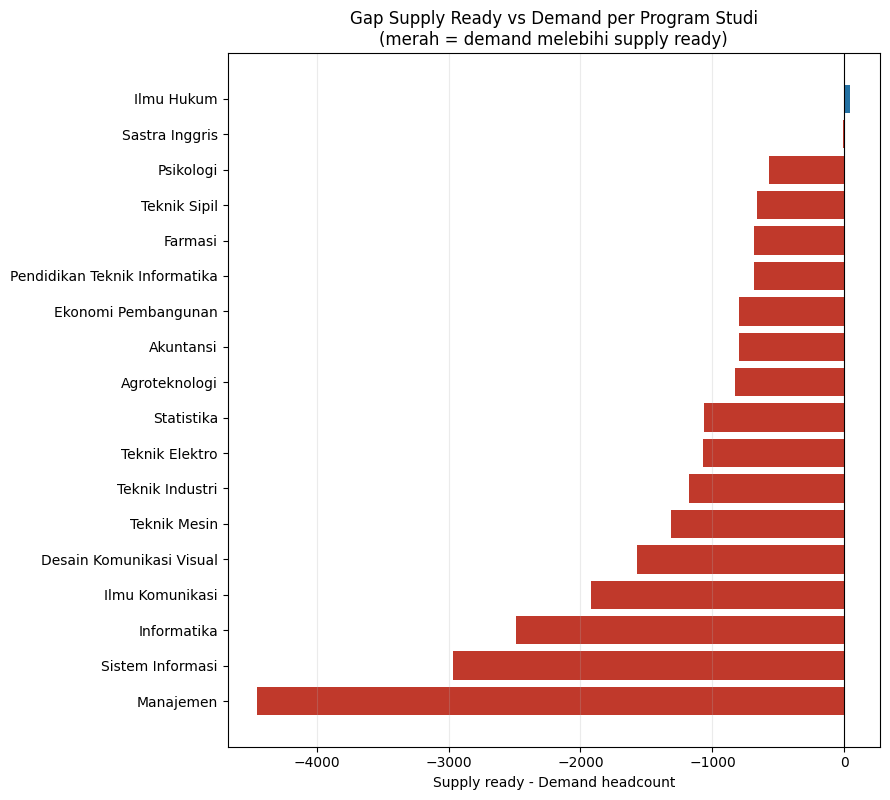

In [11]:
plot_df = demand_supply_prodi.sort_values("gap_supply_ready_minus_demand")

plt.figure(figsize=(9, max(4, len(plot_df) * 0.45)))
colors = ["#c0392b" if v < 0 else "#2471a3" for v in plot_df["gap_supply_ready_minus_demand"]]
plt.barh(plot_df["program_studi"], plot_df["gap_supply_ready_minus_demand"], color=colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Gap Supply Ready vs Demand per Program Studi\n(merah = demand melebihi supply ready)")
plt.xlabel("Supply ready - Demand headcount")
plt.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

In [12]:
shortage_prodi = demand_supply_prodi[demand_supply_prodi["gap_supply_ready_minus_demand"] < 0]
surplus_prodi = demand_supply_prodi[demand_supply_prodi["gap_supply_ready_minus_demand"] >= 0]

display(
    Markdown(
        f"""
**Interpretasi demand-supply per program studi:**

- **{len(shortage_prodi)} dari {len(demand_supply_prodi)} program studi**
  memiliki jumlah mahasiswa *basic ready* yang lebih sedikit dibanding
  estimasi demand headcount — program studi ini berisiko tidak dapat
  memenuhi seluruh permintaan perusahaan tanpa mendorong lebih banyak
  mahasiswa menyelesaikan CV/status siap.
- **{len(surplus_prodi)} program studi** memiliki supply ready lebih besar
  dari demand — berpotensi menjadi kandidat prioritas outreach ke lebih
  banyak perusahaan, atau perlu dicek apakah minat penempatan mahasiswa di
  program studi tersebut sesuai dengan posisi yang tersedia.
- Angka `demand_headcount` di sini adalah **estimasi**, karena satu request
  yang menyebut lebih dari satu program studi dibagi rata; pembagian yang
  lebih akurat memerlukan bobot prioritas program studi per request yang
  tidak tersedia di dataset.
"""
    )
)


**Interpretasi demand-supply per program studi:**

- **17 dari 18 program studi**
  memiliki jumlah mahasiswa *basic ready* yang lebih sedikit dibanding
  estimasi demand headcount — program studi ini berisiko tidak dapat
  memenuhi seluruh permintaan perusahaan tanpa mendorong lebih banyak
  mahasiswa menyelesaikan CV/status siap.
- **1 program studi** memiliki supply ready lebih besar
  dari demand — berpotensi menjadi kandidat prioritas outreach ke lebih
  banyak perusahaan, atau perlu dicek apakah minat penempatan mahasiswa di
  program studi tersebut sesuai dengan posisi yang tersedia.
- Angka `demand_headcount` di sini adalah **estimasi**, karena satu request
  yang menyebut lebih dari satu program studi dibagi rata; pembagian yang
  lebih akurat memerlukan bobot prioritas program studi per request yang
  tidak tersedia di dataset.


### Tren pertumbuhan demand vs kohort mahasiswa (proxy supply)

Dataset tidak memiliki riwayat ketersediaan mahasiswa dari waktu ke waktu
(`status_student` adalah snapshot terkini), sehingga tren supply murni tidak
bisa dibuat. Sebagai **proxy**, jumlah mahasiswa per **tahun masuk**
dibandingkan dengan jumlah talent request per **tahun request** — untuk
melihat apakah pertumbuhan basis mahasiswa sejalan dengan pertumbuhan
permintaan perusahaan.

,jumlah_talent_request,jumlah_mahasiswa_masuk
2019,0.00,"1,266.00"
2020,0.00,"3,777.00"
2021,0.00,"7,514.00"
2022,0.00,"7,420.00"
2023,"5,126.00","5,023.00"
2024,"6,269.00",0.00
2025,605.00,0.00


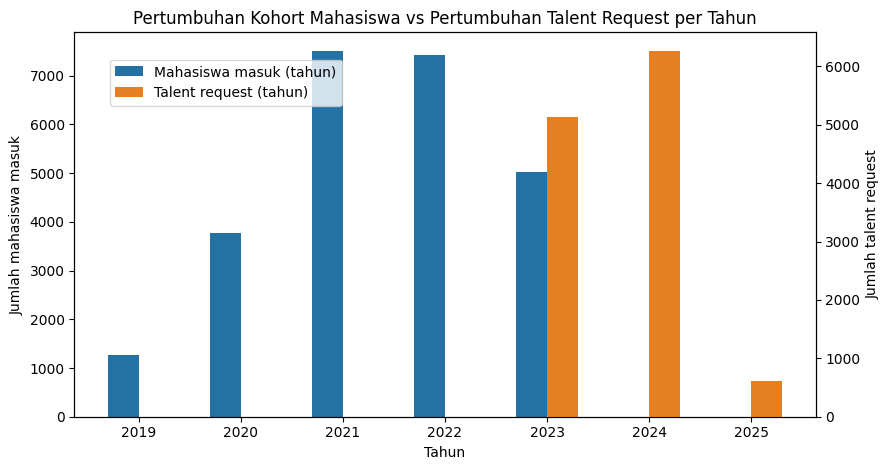

In [13]:
demand_by_year = talent_request.groupby(talent_request["request_date"].dt.year).size()
supply_by_year = student_all.groupby("entry_year").size()

trend_df = pd.DataFrame(
    {"jumlah_talent_request": demand_by_year, "jumlah_mahasiswa_masuk": supply_by_year}
).fillna(0)

display(trend_df)

fig, ax1 = plt.subplots(figsize=(9, 4.8))
ax1.bar(trend_df.index - 0.15, trend_df["jumlah_mahasiswa_masuk"], width=0.3, label="Mahasiswa masuk (tahun)", color="#2471a3")
ax1.set_ylabel("Jumlah mahasiswa masuk")
ax2 = ax1.twinx()
ax2.bar(trend_df.index + 0.15, trend_df["jumlah_talent_request"], width=0.3, label="Talent request (tahun)", color="#e67e22")
ax2.set_ylabel("Jumlah talent request")
ax1.set_xlabel("Tahun")
ax1.set_title("Pertumbuhan Kohort Mahasiswa vs Pertumbuhan Talent Request per Tahun")
fig.legend(loc="upper left", bbox_to_anchor=(0.12, 0.88))
plt.tight_layout()
plt.show()

## 4. Analisis Skill / Tools Gap (BT-01, BT-06)

`talent_request.deskripsi_requirement` berupa teks bebas, sedangkan
`status_student.tools` berupa daftar tools yang dipisah koma. Untuk
membandingkan keduanya, kosakata tools diambil dari nilai unik yang benar-benar
muncul di `status_student.tools`, lalu dicocokkan sebagai kata kunci pada
`deskripsi_requirement`.

**Catatan metode:** ini adalah pencocokan kata kunci sederhana (bukan NLP),
sehingga sinonim atau penulisan berbeda (misalnya "Ms Excel" vs "Excel")
dapat terlewat. Bagian ini juga melaporkan berapa persen request yang
berhasil dikenali minimal satu tools, sebagai ukuran keandalan ekstraksi.

In [14]:
tools_vocab = sorted(
    split_multivalue(status_student["tools"]).str.strip().unique().tolist(),
    key=len,
    reverse=True,  # cocokkan frasa lebih panjang lebih dulu (mis. "Google Analytics" sebelum "Google")
)

def extract_tools_from_text(text, vocab):
    if pd.isna(text):
        return []
    found = []
    remaining = text
    for tool in vocab:
        pattern = r"(?<![A-Za-z0-9])" + re.escape(tool) + r"(?![A-Za-z0-9])"
        if re.search(pattern, remaining, flags=re.IGNORECASE):
            found.append(tool)
    return found

talent_request["extracted_tools"] = talent_request["deskripsi_requirement"].apply(
    lambda text: extract_tools_from_text(text, tools_vocab)
)
talent_request["extracted_tools_count"] = talent_request["extracted_tools"].str.len()

coverage_pct = (talent_request["extracted_tools_count"] > 0).mean() * 100
print(
    f"Request yang berhasil dikenali minimal 1 tools lewat pencocokan kata kunci: "
    f"{coverage_pct:.1f}% dari {len(talent_request):,} request."
)

Request yang berhasil dikenali minimal 1 tools lewat pencocokan kata kunci: 38.7% dari 12,000 request.


In [15]:
tool_demand_rows = talent_request.explode("extracted_tools").dropna(subset=["extracted_tools"])
tool_demand = (
    tool_demand_rows.groupby("extracted_tools")
    .agg(
        demand_headcount=("headcount", "sum"),
        jumlah_request=("id_talent_req", "nunique"),
    )
    .rename_axis("tool")
)

tool_supply_exploded = (
    status_student[["nim", "tools", "basic_ready"]]
    .dropna(subset=["tools"])
    .assign(tool=lambda d: d["tools"].str.split(","))
    .explode("tool")
)
tool_supply_exploded["tool"] = tool_supply_exploded["tool"].str.strip()

tool_supply = (
    tool_supply_exploded.groupby("tool")
    .agg(
        supply_total=("nim", "nunique"),
        supply_ready=("basic_ready", "sum"),
    )
)

tools_gap = tool_demand.join(tool_supply, how="outer").fillna(0)
tools_gap["gap_ready_minus_demand"] = tools_gap["supply_ready"] - tools_gap["demand_headcount"]
tools_gap = tools_gap.sort_values("gap_ready_minus_demand")

display(tools_gap)

,demand_headcount,jumlah_request,supply_total,supply_ready,gap_ready_minus_demand
tool,,,,,
SQL,4761,"1,969.00",4850,989,-3772
R,3531,"1,478.00",1802,437,-3094
Python,4284,"1,784.00",5122,1214,-3070
Tableau,3322,"1,393.00",1811,439,-2883
Power BI,3322,"1,393.00",3353,631,-2691
...,...,...,...,...,...
WordPress,0,0.00,1322,327,327
Canva,0,0.00,2422,360,360
MATLAB,0,0.00,2457,597,597


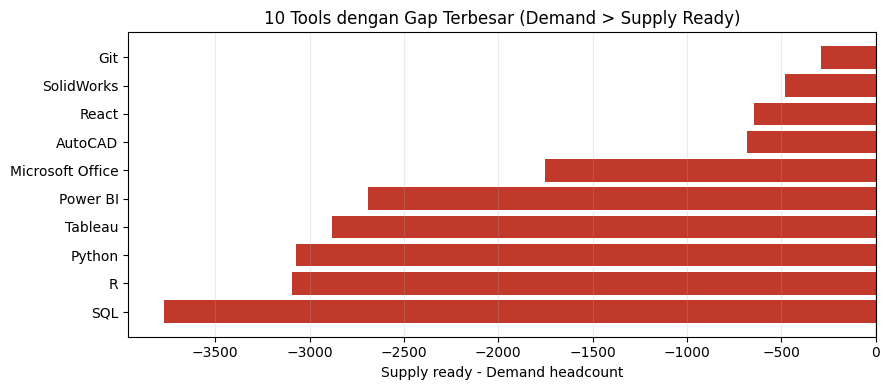

In [16]:
top_shortage = tools_gap.head(10).sort_values("gap_ready_minus_demand")

plt.figure(figsize=(9, max(4, len(top_shortage) * 0.4)))
plt.barh(top_shortage.index, top_shortage["gap_ready_minus_demand"], color="#c0392b")
plt.axvline(0, color="black", linewidth=0.8)
plt.title("10 Tools dengan Gap Terbesar (Demand > Supply Ready)")
plt.xlabel("Supply ready - Demand headcount")
plt.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

In [17]:
most_short = tools_gap.index[0] if len(tools_gap) else None
most_surplus = tools_gap.index[-1] if len(tools_gap) else None

display(
    Markdown(
        f"""
**Interpretasi skill/tools gap:**

- Tools dengan gap paling negatif (paling banyak diminta dibanding jumlah
  mahasiswa *ready* yang menguasainya) pada data ini adalah
  **{most_short}**.
- Tools dengan gap paling positif (paling banyak dikuasai mahasiswa
  dibanding permintaan) adalah **{most_surplus}**.
- Tools dengan gap negatif signifikan adalah kandidat prioritas untuk
  pelatihan/upskilling mahasiswa oleh CDC, atau perlu dicek apakah requirement
  di lapangan memang seketat itu.
- Karena ekstraksi berbasis kata kunci ({coverage_pct:.0f}% cakupan),
  angka `demand_headcount` di tabel ini adalah **batas bawah** (kemungkinan
  under-count) — bukan jumlah permintaan tools yang pasti.
"""
    )
)


**Interpretasi skill/tools gap:**

- Tools dengan gap paling negatif (paling banyak diminta dibanding jumlah
  mahasiswa *ready* yang menguasainya) pada data ini adalah
  **SQL**.
- Tools dengan gap paling positif (paling banyak dikuasai mahasiswa
  dibanding permintaan) adalah **SPSS**.
- Tools dengan gap negatif signifikan adalah kandidat prioritas untuk
  pelatihan/upskilling mahasiswa oleh CDC, atau perlu dicek apakah requirement
  di lapangan memang seketat itu.
- Karena ekstraksi berbasis kata kunci (39% cakupan),
  angka `demand_headcount` di tabel ini adalah **batas bawah** (kemungkinan
  under-count) — bukan jumlah permintaan tools yang pasti.


## 5. Rule-Based Talent Matching (BT-01, BT-06)

Mengikuti definisi `basic_eligible` dan `request_eligible` pada dokumentasi
dataset (bagian 7.4), kelayakan dan skor kecocokan dibangun sebagai berikut:

**Kelayakan dasar (`basic_ready`)** — sudah dihitung sebelumnya:
status Active, ketersediaan Available, CV Ada.

**Kelayakan terhadap request (`request_eligible`)** — basic_ready ditambah:
semester mahasiswa >= `minimum_semester`, dan program studi mahasiswa
termasuk dalam `bidang_studi_dibutuhkan`.

**Skor kecocokan (0-100)** untuk mahasiswa yang *request_eligible*:

| Komponen | Bobot |
|---|---|
| Kecocokan program studi | 35 |
| Overlap tools (tools mahasiswa vs tools yang diekstrak dari requirement) | 30 |
| Kecocokan jenis penempatan yang diminati | 20 |
| Portofolio tersedia | 15 |

Bobot ini adalah titik awal yang wajar berdasarkan kolom yang tersedia,
bukan hasil optimisasi — sebaiknya didiskusikan ulang bersama tim sebelum
dipakai sebagai keputusan final di laporan.

In [18]:
def tools_overlap_ratio(student_tools, required_tools):
    if not required_tools:
        return 0.0
    student_set = {t.strip().lower() for t in (student_tools or "").split(",") if t.strip()}
    required_set = {t.strip().lower() for t in required_tools}
    if not required_set:
        return 0.0
    return len(student_set & required_set) / len(required_set)


eligible_students = student_readiness_mart[student_readiness_mart["basic_ready"]].copy()
open_requests = talent_request_mart[talent_request_mart["is_open"]].copy()

print(
    f"Mahasiswa basic ready: {len(eligible_students):,} dari "
    f"{len(student_readiness_mart):,} total mahasiswa."
)
print(
    f"Talent request masih terbuka (backlog > 0): {len(open_requests):,} dari "
    f"{len(talent_request_mart):,} total request."
)

Mahasiswa basic ready: 5,687 dari 25,000 total mahasiswa.
Talent request masih terbuka (backlog > 0): 10,032 dari 12,000 total request.


In [19]:
match_rows = []

for _, req in open_requests.iterrows():
    required_prodi = [
        p.strip() for p in str(req["bidang_studi_dibutuhkan"]).split(",") if p.strip()
    ]
    required_tools = extract_tools_from_text(req.get("deskripsi_requirement"), tools_vocab) \
        if "deskripsi_requirement" in req else []
    candidates = eligible_students[
        eligible_students["program_studi"].isin(required_prodi)
        & (eligible_students["semester"] >= req["minimum_semester"])
    ]

    for _, stu in candidates.iterrows():
        prodi_score = 35 if stu["program_studi"] in required_prodi else 0
        tools_score = 30 * tools_overlap_ratio(stu["tools"], required_tools)
        placement_score = (
            20 if stu["jenis_penempatan_diminati"] == req["jenis_penempatan"] else 0
        )
        portfolio_score = 15 if stu["portofolio"] == "Ada" else 0
        total_score = prodi_score + tools_score + placement_score + portfolio_score

        match_rows.append({
            "id_talent_req": req["id_talent_req"],
            "nama_posisi": req["nama_posisi"],
            "company_name": req["company_name"],
            "backlog_headcount": req["backlog_headcount"],
            "nim": stu["nim"],
            "program_studi": stu["program_studi"],
            "semester": stu["semester"],
            "match_score": round(total_score, 1),
        })

match_table = pd.DataFrame(match_rows)
has_matches = not match_table.empty

if not has_matches:
    top_matches = pd.DataFrame()
    print("Tidak ada kandidat yang memenuhi kelayakan dasar untuk request terbuka saat ini.")
else:
    match_table = match_table.sort_values(
        ["id_talent_req", "match_score"], ascending=[True, False]
    )
    top_matches = (
        match_table.groupby("id_talent_req")
        .head(5)
        .reset_index(drop=True)
    )
    print(f"Rekomendasi kandidat dibuat untuk {top_matches['id_talent_req'].nunique():,} request terbuka.")
    display(top_matches.head(15))

Rekomendasi kandidat dibuat untuk 10,032 request terbuka.


,id_talent_req,nama_posisi,company_name,backlog_headcount,nim,program_studi,semester,match_score
0,TR001,Project Coordinator Intern,PT Prima Data,2,20210265,Teknik Industri,7,70.00
1,TR001,Project Coordinator Intern,PT Prima Data,2,20210885,Manajemen,6,70.00
2,TR001,Project Coordinator Intern,PT Prima Data,2,20200948,Teknik Industri,7,70.00
3,TR001,Project Coordinator Intern,PT Prima Data,2,20211235,Manajemen,6,70.00
4,TR001,Project Coordinator Intern,PT Prima Data,2,20201362,Teknik Industri,7,70.00
5,TR002,Quality Control Staff,PT Sentosa Teknologi,3,20200059,Farmasi,9,70.00
6,TR002,Quality Control Staff,PT Sentosa Teknologi,3,20200620,Farmasi,7,70.00
7,TR002,Quality Control Staff,PT Sentosa Teknologi,3,20200670,Teknik Mesin,7,70.00
8,TR002,Quality Control Staff,PT Sentosa Teknologi,3,20200723,Teknik Mesin,8,70.00
9,TR002,Quality Control Staff,PT Sentosa Teknologi,3,20191941,Teknik Mesin,9,70.00


### Validasi aturan terhadap hasil placement historis

Aturan kelayakan di atas dibangun dari logika dokumentasi, bukan dari data
historis. Untuk memeriksa masuk akal atau tidaknya aturan ini, kandidat yang
**benar-benar diterima (`Placement`)** di masa lalu diperiksa: berapa persen
dari mereka yang, berdasarkan kondisi mereka saat ini di `status_student`,
akan lolos filter `request_eligible`?

**Catatan penting:** `status_student` adalah snapshot *terkini*, sedangkan
placement terjadi di masa lalu — kondisi mahasiswa (semester, ketersediaan)
saat placement mungkin berbeda dari sekarang. Angka ini adalah **indikasi
awal**, bukan pengukuran akurasi model yang presisi.

In [20]:
placed = candidate_pipeline_mart[candidate_pipeline_mart["outcome_group"].eq("Placement")].copy()

current_condition = student_readiness_mart[["nim", "semester", "basic_ready"]].rename(
    columns={"semester": "semester_current", "basic_ready": "basic_ready_current"}
)
placed_check = placed.merge(current_condition, on="nim", how="left")
placed_check["prodi_would_match"] = placed_check.apply(
    lambda r: r["program_studi"] in str(r["bidang_studi_dibutuhkan"]).split(","),
    axis=1,
)
placed_check["semester_would_pass"] = (
    placed_check["semester_current"] >= placed_check["minimum_semester"]
)
placed_check["would_pass_rule_today"] = (
    placed_check["basic_ready_current"]
    & placed_check["prodi_would_match"]
    & placed_check["semester_would_pass"]
)

pass_rate = placed_check["would_pass_rule_today"].mean() * 100 if len(placed_check) else float("nan")

display(
    Markdown(
        f"""
**Hasil validasi:**

- Dari **{len(placed_check):,} placement historis**, **{pass_rate:.1f}%**
  mahasiswa yang berhasil ditempatkan memenuhi kombinasi aturan
  (program studi cocok + semester saat ini memenuhi syarat + basic ready
  saat ini).
- Selisih dari 100% wajar terjadi karena kondisi mahasiswa berubah
  setelah placement (semester bertambah, ketersediaan berubah menjadi
  `Placed`). Untuk validasi yang lebih akurat, idenya diperiksa terhadap
  snapshot status mahasiswa **pada saat proses seleksi berjalan**, bukan
  snapshot terkini.
"""
    )
)


**Hasil validasi:**

- Dari **8,955 placement historis**, **2.2%**
  mahasiswa yang berhasil ditempatkan memenuhi kombinasi aturan
  (program studi cocok + semester saat ini memenuhi syarat + basic ready
  saat ini).
- Selisih dari 100% wajar terjadi karena kondisi mahasiswa berubah
  setelah placement (semester bertambah, ketersediaan berubah menjadi
  `Placed`). Untuk validasi yang lebih akurat, idenya diperiksa terhadap
  snapshot status mahasiswa **pada saat proses seleksi berjalan**, bukan
  snapshot terkini.


## 6. Funnel Seleksi, Acceptance Rate, dan Ghosting (BT-02, BT-04, BT-05)

Bagian ini bekerja di grain `candidate_pipeline_mart` (1 mahasiswa x 1
proses). *Acceptance rate* dan *ghosting rate* dihitung terhadap proses
yang **sudah memiliki outcome tegas** (`Placement`, `Rejected`, `Ghosting`),
mengeluarkan proses yang masih `On Progress` atau `Finish - Unclear` dari
penyebut, supaya rate tidak bias oleh proses yang belum selesai.

In [21]:
definite_outcomes = ["Placement", "Rejected", "Ghosting"]
definite = candidate_pipeline_mart[candidate_pipeline_mart["outcome_group"].isin(definite_outcomes)]

overall_funnel = candidate_pipeline_mart["outcome_group"].value_counts()
display(overall_funnel.to_frame("jumlah_proses"))

overall_acceptance = (definite["outcome_group"].eq("Placement").mean() * 100) if len(definite) else float("nan")
overall_ghosting = (definite["outcome_group"].eq("Ghosting").mean() * 100) if len(definite) else float("nan")

print(f"Acceptance rate keseluruhan (dari proses dengan outcome tegas): {overall_acceptance:.1f}%")
print(f"Ghosting rate keseluruhan (dari proses dengan outcome tegas): {overall_ghosting:.1f}%")

,jumlah_proses
outcome_group,
On Progress,14910
Rejected,11736
Placement,8955
Ghosting,3421
Finish - Unclear,2578


Acceptance rate keseluruhan (dari proses dengan outcome tegas): 37.1%
Ghosting rate keseluruhan (dari proses dengan outcome tegas): 14.2%


In [22]:
MIN_SAMPLE = 5  # ambang jumlah proses minimum agar rate per kelompok tidak bising

def rate_by_group(df, group_col, min_sample=MIN_SAMPLE):
    definite_df = df[df["outcome_group"].isin(definite_outcomes)]
    grouped = (
        definite_df.groupby(group_col)["outcome_group"]
        .agg(
            jumlah_proses_tegas="count",
            acceptance_rate=lambda s: (s.eq("Placement").mean() * 100),
            ghosting_rate=lambda s: (s.eq("Ghosting").mean() * 100),
            rejection_rate=lambda s: (s.eq("Rejected").mean() * 100),
        )
    )
    return grouped[grouped["jumlah_proses_tegas"] >= min_sample].sort_values(
        "acceptance_rate", ascending=False
    )


acceptance_by_company = rate_by_group(candidate_pipeline_mart, "company_name")
acceptance_by_prodi = rate_by_group(candidate_pipeline_mart, "program_studi")
acceptance_by_sector = rate_by_group(candidate_pipeline_mart, "industry_sector")

display(Markdown(f"### Acceptance & ghosting rate per perusahaan (min. {MIN_SAMPLE} proses)"))
display(acceptance_by_company)

display(Markdown(f"### Acceptance & ghosting rate per program studi (min. {MIN_SAMPLE} proses)"))
display(acceptance_by_prodi)

display(Markdown(f"### Acceptance & ghosting rate per sektor industri (min. {MIN_SAMPLE} proses)"))
display(acceptance_by_sector)

### Acceptance & ghosting rate per perusahaan (min. 5 proses)

,jumlah_proses_tegas,acceptance_rate,ghosting_rate,rejection_rate
company_name,,,,
PT Sukses Gemilang,5,100.00,0.00,0.00
CV Jaya Solusi,6,83.33,0.00,16.67
CV Inovasi Solusi,6,83.33,0.00,16.67
CV Abadi Bangsa,5,80.00,0.00,20.00
PT Solusi Digital,5,80.00,0.00,20.00
...,...,...,...,...
CV Inti Inovasi,5,0.00,0.00,100.00
CV Global Sejahtera,8,0.00,12.50,87.50
PT Kreasi Kreatif,10,0.00,10.00,90.00


### Acceptance & ghosting rate per program studi (min. 5 proses)

,jumlah_proses_tegas,acceptance_rate,ghosting_rate,rejection_rate
program_studi,,,,
Sastra Inggris,138,43.48,14.49,42.03
Teknik Industri,1402,39.87,14.48,45.65
Psikologi,566,38.87,12.72,48.41
Akuntansi,1109,38.68,14.61,46.71
Statistika,885,38.19,11.64,50.17
Pendidikan Teknik Informatika,804,37.81,14.43,47.76
Teknik Sipil,671,37.41,14.61,47.99
Informatika,3183,37.17,13.95,48.88
Manajemen,4547,37.15,14.16,48.69


### Acceptance & ghosting rate per sektor industri (min. 5 proses)

,jumlah_proses_tegas,acceptance_rate,ghosting_rate,rejection_rate
industry_sector,,,,
Agribisnis,1322,38.58,12.33,49.09
Keuangan & Perbankan,1461,38.33,14.17,47.50
Konsultan Manajemen,1269,38.30,14.26,47.44
Properti & Konstruksi,1168,38.18,14.04,47.77
Retail,1777,37.93,15.08,46.99
Logistik & Supply Chain,1456,37.91,14.56,47.53
Asuransi,1723,37.61,13.70,48.69
Otomotif,1323,37.57,14.29,48.15
Telekomunikasi,1241,37.31,13.94,48.75


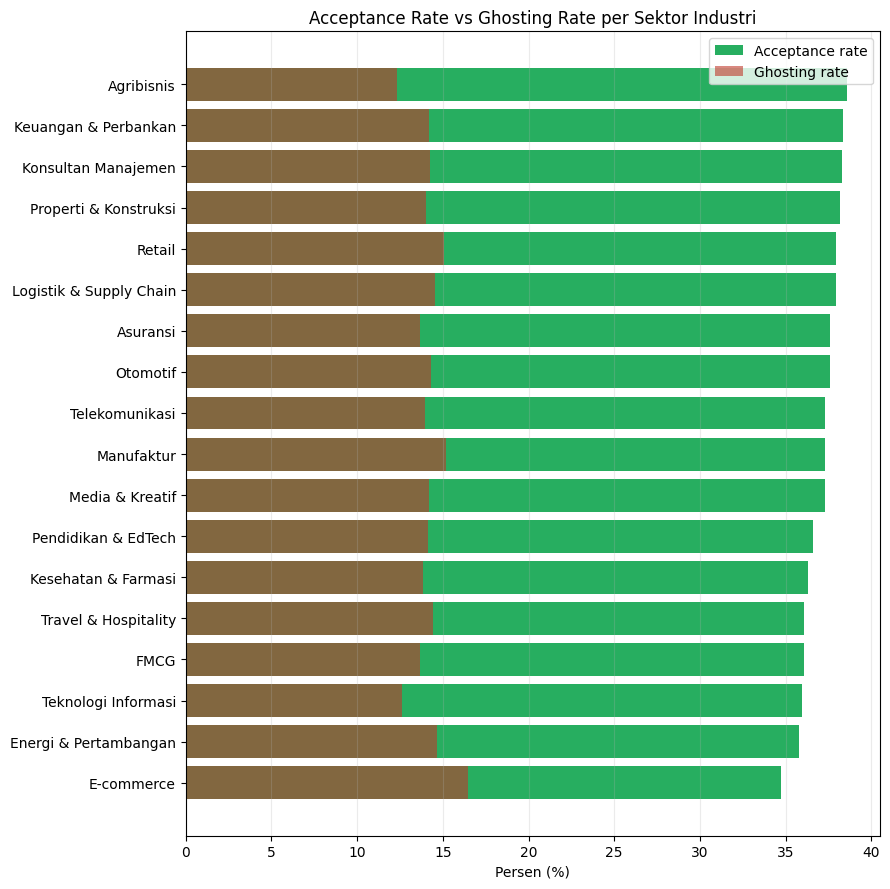

In [23]:
if len(acceptance_by_sector):
    plot_df = acceptance_by_sector.reset_index().sort_values("acceptance_rate")
    fig, ax = plt.subplots(figsize=(9, max(4, len(plot_df) * 0.5)))
    ax.barh(plot_df["industry_sector"], plot_df["acceptance_rate"], color="#27ae60", label="Acceptance rate")
    ax.barh(plot_df["industry_sector"], plot_df["ghosting_rate"], color="#c0392b", alpha=0.6, label="Ghosting rate")
    ax.set_title("Acceptance Rate vs Ghosting Rate per Sektor Industri")
    ax.set_xlabel("Persen (%)")
    ax.legend()
    ax.grid(axis="x", alpha=0.25)
    plt.tight_layout()
    plt.show()
else:
    print("Belum ada sektor dengan jumlah proses tegas mencukupi ambang minimum.")

### Proses yang berpotensi ghosting (belum ada respons, sudah lama tidak diperbarui)

Dataset tidak memiliki label "ghosting yang akan terjadi", tetapi proses
yang masih `On Progress` dan **sudah lama tidak diperbarui** (`days_since_update`
tinggi) adalah kandidat kuat untuk *follow-up* segera — konsisten dengan
alur bisnis FU 1/FU 2/FU 3 pada dokumentasi dataset.

In [24]:
stale_threshold_days = int(candidate_pipeline_mart["days_since_update"].quantile(0.75))

at_risk = candidate_pipeline_mart[
    candidate_pipeline_mart["outcome_group"].eq("On Progress")
    & (candidate_pipeline_mart["days_since_update"] >= stale_threshold_days)
].sort_values("days_since_update", ascending=False)

print(
    f"Ambang 'lama tidak update' dipakai: >= {stale_threshold_days} hari "
    f"(kuartil atas dari seluruh proses)."
)
print(f"Jumlah proses On Progress yang berisiko ghosting: {len(at_risk):,}")
display(
    at_risk[[
        "id_tracking_student", "nim", "company_name", "position",
        "progress_student", "days_since_update",
    ]].head(15)
)

Ambang 'lama tidak update' dipakai: >= 567 hari (kuartil atas dari seluruh proses).
Jumlah proses On Progress yang berisiko ghosting: 4,078


,id_tracking_student,nim,company_name,position,progress_student,days_since_update
1376,TS1377,202112349,CV Cakra Terapan,IT Staff,Selecting Student by Company,829
6679,TS6680,202222900,PT Sejahtera Informatika,Business Analyst,Selecting Student by Company,825
1377,TS1378,202113780,CV Cakra Terapan,IT Staff,Study Case,821
2663,TS2664,202224488,CV Andalas Data,Backend Developer,Selecting Student by Company,821
7537,TS7538,202315773,PT Mega Perkasa,Customer Success Intern,Selecting Student by Company,821
5070,TS5071,202212066,PT Indo Sentosa,Electrical Engineer Intern,Selecting Student by Company,820
4441,TS4442,20218320,PT Prima Logistik,Environmental Analyst,Selecting Student by Company,820
7846,TS7847,20191383,CV Bakti Mandiri,Data Engineer,Selecting Student by Company,819
7538,TS7539,202223370,PT Mega Perkasa,Customer Success Intern,Selecting Student by Company,819
7202,TS7203,202210692,PT Global Teknologi,Pharmacist Intern,Selecting Student by Company,818


## 7. Prioritas Talent Request / Manajemen Backlog (BT-03)

Setiap request terbuka (`backlog_headcount > 0`) diplot berdasarkan **usia
request** (semakin lama semakin mendesak) dan **jumlah kekurangan kandidat**
(`backlog_headcount`). Kuadran kanan-atas adalah request yang paling
mendesak untuk diprioritaskan CDC.

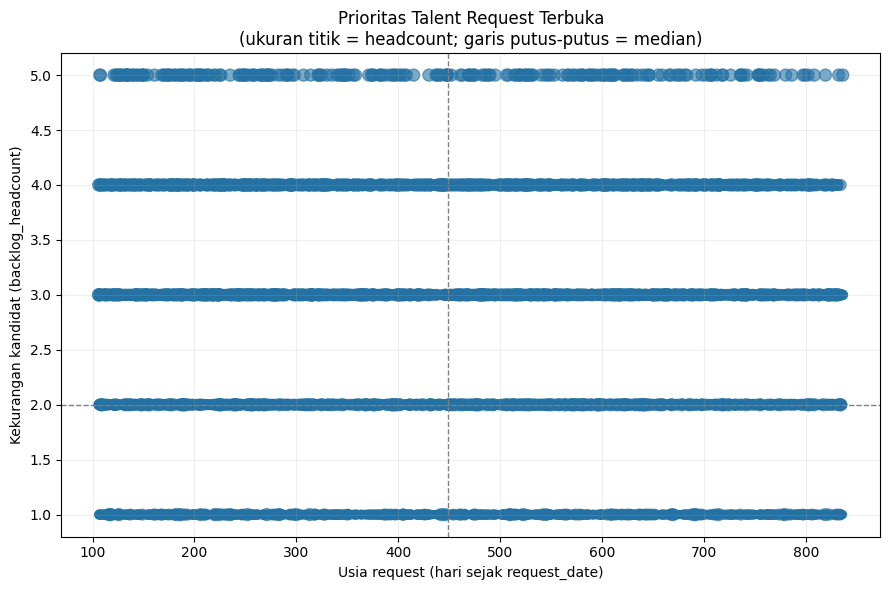

In [25]:
priority_df = talent_request_mart[talent_request_mart["is_open"]].copy()

age_median = priority_df["request_age_days"].median()
backlog_median = priority_df["backlog_headcount"].median()

plt.figure(figsize=(9, 6))
sizes = (priority_df["headcount"].astype(float) * 15).clip(lower=20)
plt.scatter(
    priority_df["request_age_days"],
    priority_df["backlog_headcount"],
    s=sizes,
    alpha=0.6,
    c="#2471a3",
)
plt.axvline(age_median, color="grey", linestyle="--", linewidth=1)
plt.axhline(backlog_median, color="grey", linestyle="--", linewidth=1)
plt.title("Prioritas Talent Request Terbuka\n(ukuran titik = headcount; garis putus-putus = median)")
plt.xlabel("Usia request (hari sejak request_date)")
plt.ylabel("Kekurangan kandidat (backlog_headcount)")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

In [26]:
urgent_requests = priority_df[
    (priority_df["request_age_days"] >= age_median)
    & (priority_df["backlog_headcount"] >= backlog_median)
].sort_values(["request_age_days", "backlog_headcount"], ascending=False)

print(f"Request pada kuadran paling mendesak (usia & backlog di atas median): {len(urgent_requests):,}")
display(
    urgent_requests[[
        "id_talent_req", "company_name", "nama_posisi", "request_age_days",
        "backlog_headcount", "headcount", "coverage_ratio_request", "progress_terakhir",
    ]].head(15)
)

Request pada kuadran paling mendesak (usia & backlog di atas median): 3,021


,id_talent_req,company_name,nama_posisi,request_age_days,backlog_headcount,headcount,coverage_ratio_request,progress_terakhir
1402,TR1403,CV Techno Systems,Digital Marketing Intern,836,5,5,1.20,Shortlisted
965,TR966,PT Bumi Logistik,Electrical Engineer Intern,836,3,3,1.33,Closed
1683,TR1684,CV Inovasi Solusi,Research Associate,836,3,3,0.00,Draft
910,TR911,PT Makmur Teknologi,Data Analyst,836,2,2,1.00,On Review
1411,TR1412,PT Sukses Inovasi,Brand Executive Intern,836,2,2,1.00,On Review
858,TR859,PT Bakti Inovasi,Brand Executive Intern,835,3,3,1.00,Shortlisted
409,TR410,CV Cakra Terapan,IT Staff,835,2,2,1.50,Submitted
2071,TR2072,PT Global Teknologi,Pharmacist Intern,835,2,3,1.67,On Review
2338,TR2339,PT Bumi Digital,Data Analyst,835,2,3,1.33,On Review
1011,TR1012,CV Cakra Analitika,IT Support,834,4,4,1.25,On Review


In [27]:
priority_summary = pd.Series(
    {
        "jumlah_request_terbuka": len(priority_df),
        "total_backlog_headcount": int(priority_df["backlog_headcount"].sum()),
        "median_usia_request_hari": age_median,
        "jumlah_request_prioritas_mendesak": len(urgent_requests),
        "request_belum_ada_pengiriman_sama_sekali": int(
            (priority_df["total_dikirimkan"] == 0).sum()
        ),
    },
    name="ringkasan_prioritas",
)
display(priority_summary.to_frame())

,ringkasan_prioritas
jumlah_request_terbuka,"10,032.00"
total_backlog_headcount,"20,092.00"
median_usia_request_hari,449.00
jumlah_request_prioritas_mendesak,"3,021.00"
request_belum_ada_pengiriman_sama_sekali,598.00


## 8. Tindak Lanjut Kualitas Data (BT-08)

Ringkas, karena pemeriksaan primary key/foreign key detail sudah dilakukan
di notebook 1. Bagian ini berfokus pada isu yang **berdampak langsung ke
analisis lintas tabel** di notebook ini: sinkronisasi `student_all` dengan
`status_student`, dan proporsi `Finish - Unclear` yang perlu diputuskan
sebelum KPI keberhasilan dilaporkan final.

In [28]:
sync_gap = (~student_readiness_mart["has_status_record"]).sum()
stale_sync = (status_student["days_since_sync"] > 30).sum()
finish_unclear_count = tracking_student["outcome_group"].eq("Finish - Unclear").sum()
finish_unclear_pct = finish_unclear_count / len(tracking_student) * 100

data_quality_followup = pd.Series(
    {
        "mahasiswa_tanpa_status_student": int(sync_gap),
        "status_student_sinkronisasi_lebih_dari_30_hari": int(stale_sync),
        "proses_finish_unclear": int(finish_unclear_count),
        "persentase_finish_unclear": round(finish_unclear_pct, 2),
    },
    name="tindak_lanjut_kualitas_data",
)
display(data_quality_followup.to_frame())

display(
    Markdown(
        f"""
**Rekomendasi tindak lanjut:**

- **{sync_gap:,} mahasiswa** ada di `student_all` tetapi belum punya baris
  `status_student` — mereka tidak bisa dinilai kelayakannya sama sekali dan
  otomatis tidak muncul di rekomendasi matching manapun. Perlu ditelusuri
  apakah ini keterlambatan sinkronisasi atau mahasiswa yang memang belum
  mengisi status.
- **{finish_unclear_count:,} proses ({finish_unclear_pct:.1f}%)** berstatus
  `Finish` tanpa outcome akhir yang jelas. Sebelum acceptance rate final
  dilaporkan di laporan penulisan, kelompok ini perlu diputuskan: apakah
  dianggap `Rejected` diam-diam, `Placement` yang belum ditandai, atau
  dikeluarkan dari perhitungan rate.
"""
    )
)

,tindak_lanjut_kualitas_data
mahasiswa_tanpa_status_student,0.00
status_student_sinkronisasi_lebih_dari_30_hari,"23,905.00"
proses_finish_unclear,"2,578.00"
persentase_finish_unclear,6.20



**Rekomendasi tindak lanjut:**

- **0 mahasiswa** ada di `student_all` tetapi belum punya baris
  `status_student` — mereka tidak bisa dinilai kelayakannya sama sekali dan
  otomatis tidak muncul di rekomendasi matching manapun. Perlu ditelusuri
  apakah ini keterlambatan sinkronisasi atau mahasiswa yang memang belum
  mengisi status.
- **2,578 proses (6.2%)** berstatus
  `Finish` tanpa outcome akhir yang jelas. Sebelum acceptance rate final
  dilaporkan di laporan penulisan, kelompok ini perlu diputuskan: apakah
  dianggap `Rejected` diam-diam, `Placement` yang belum ditandai, atau
  dikeluarkan dari perhitungan rate.


## 9. Ringkasan Insight Strategis dan Rekomendasi

### Ringkasan lintas bagian

In [29]:
top_shortage_prodi = demand_supply_prodi.iloc[0]["program_studi"] if len(demand_supply_prodi) else "-"
top_shortage_tool = tools_gap.index[0] if len(tools_gap) else "-"
best_sector = (
    acceptance_by_sector["acceptance_rate"].idxmax()
    if len(acceptance_by_sector) else "-"
)
worst_ghosting_sector = (
    acceptance_by_sector["ghosting_rate"].idxmax()
    if len(acceptance_by_sector) else "-"
)

display(
    Markdown(
        f"""
| Area analisis | Temuan utama pada data ini |
|---|---|
| Demand-supply | Program studi dengan gap supply-ready terbesar: **{top_shortage_prodi}** |
| Skill/tools gap | Tools dengan gap terbesar (demand > supply ready): **{top_shortage_tool}** |
| Matching | {top_matches['id_talent_req'].nunique() if has_matches else 0} dari {len(open_requests):,} request terbuka mendapat rekomendasi kandidat basic-ready |
| Funnel & ghosting | Acceptance rate tertinggi di sektor **{best_sector}**; ghosting rate tertinggi di sektor **{worst_ghosting_sector}** |
| Prioritas request | **{len(urgent_requests):,} request** berada di kuadran paling mendesak (usia & backlog di atas median) |
| Kualitas data | **{finish_unclear_count:,}** proses `Finish - Unclear` perlu keputusan sebelum KPI final dilaporkan |

### Menjawab pertanyaan analisis: apakah demand-supply, skill gap, dan job matching cocok untuk dataset ini?

**Ya, dan bukan sekadar cocok — ketiganya adalah inti dari BT-01, BT-03, BT-04,
dan BT-06.** Struktur dataset (dua sisi: `student_all`/`status_student`
sebagai supply, `talent_request` sebagai demand, dijembatani `tools` dan
`bidang_studi_dibutuhkan`) memang dirancang untuk analisis ini, sebagaimana
disebutkan eksplisit di bagian kesimpulan dokumentasi dataset. Ketiga
analisis pada notebook ini saling melengkapi:

- **Demand-supply** menjawab pertanyaan tingkat program studi/kebijakan:
  program studi mana yang perlu didorong lebih banyak mendaftar CDC.
- **Skill/tools gap** menjawab pertanyaan tingkat kurikulum/pelatihan: skill
  spesifik apa yang paling kurang.
- **Job matching** menjawab pertanyaan operasional harian CDC: mahasiswa
  spesifik mana yang paling cocok untuk request yang masih terbuka
  sekarang.

Untuk dashboard SSDC (bobot Desain 30% + Interaktivitas 20% + Relevansi
30% + Kualitas Analisis 25% di laporan), ketiga hal ini juga memberi bahan
konkret untuk fitur interaktif: filter program studi pada peta gap,
drill-down dari sektor ke perusahaan pada funnel, dan tabel rekomendasi
kandidat yang bisa difilter per request.

### Rekomendasi struktur dashboard (Tableau/Power BI/Streamlit)

1. **Halaman Ringkasan (Overview):** KPI card (jumlah mahasiswa, request,
   placement, acceptance rate, ghosting rate) + tren bulanan.
2. **Halaman Demand vs Supply:** peta/bar gap per program studi, filter
   jenis penempatan dan sektor.
3. **Halaman Skill Gap:** bar top-shortage tools, drill-down ke request
   yang menyebut tools tersebut.
4. **Halaman Funnel & Performa Perusahaan:** funnel tahap seleksi,
   acceptance/ghosting rate per perusahaan/sektor dengan filter minimum
   sample size.
5. **Halaman Prioritas Request:** scatter usia vs backlog, tabel request
   mendesak yang bisa diurutkan/difilter recruiter CDC.
6. **(Opsional, internal) Halaman Rekomendasi Matching:** tabel kandidat
   basic-ready teratas per request terbuka — perlu disamarkan identitas
   mahasiswa (lihat catatan privasi di bawah) jika dashboard bersifat
   publik.

### Catatan privasi untuk dashboard publik

Sesuai bagian privasi & etika pada dokumentasi dataset: jangan menampilkan
NIM lengkap, nama mahasiswa penuh, nomor telepon/e-mail, atau identitas PIC
perusahaan pada dashboard publik. Gunakan agregasi (jumlah, rate, rank
tanpa nama) untuk seluruh visual publik; tabel individual (termasuk hasil
matching di atas) sebaiknya dibatasi untuk kebutuhan internal CDC saja.
"""
    )
)


| Area analisis | Temuan utama pada data ini |
|---|---|
| Demand-supply | Program studi dengan gap supply-ready terbesar: **Manajemen** |
| Skill/tools gap | Tools dengan gap terbesar (demand > supply ready): **SQL** |
| Matching | 10032 dari 10,032 request terbuka mendapat rekomendasi kandidat basic-ready |
| Funnel & ghosting | Acceptance rate tertinggi di sektor **Agribisnis**; ghosting rate tertinggi di sektor **E-commerce** |
| Prioritas request | **3,021 request** berada di kuadran paling mendesak (usia & backlog di atas median) |
| Kualitas data | **2,578** proses `Finish - Unclear` perlu keputusan sebelum KPI final dilaporkan |

### Menjawab pertanyaan analisis: apakah demand-supply, skill gap, dan job matching cocok untuk dataset ini?

**Ya, dan bukan sekadar cocok — ketiganya adalah inti dari BT-01, BT-03, BT-04,
dan BT-06.** Struktur dataset (dua sisi: `student_all`/`status_student`
sebagai supply, `talent_request` sebagai demand, dijembatani `tools` dan
`bidang_studi_dibutuhkan`) memang dirancang untuk analisis ini, sebagaimana
disebutkan eksplisit di bagian kesimpulan dokumentasi dataset. Ketiga
analisis pada notebook ini saling melengkapi:

- **Demand-supply** menjawab pertanyaan tingkat program studi/kebijakan:
  program studi mana yang perlu didorong lebih banyak mendaftar CDC.
- **Skill/tools gap** menjawab pertanyaan tingkat kurikulum/pelatihan: skill
  spesifik apa yang paling kurang.
- **Job matching** menjawab pertanyaan operasional harian CDC: mahasiswa
  spesifik mana yang paling cocok untuk request yang masih terbuka
  sekarang.

Untuk dashboard SSDC (bobot Desain 30% + Interaktivitas 20% + Relevansi
30% + Kualitas Analisis 25% di laporan), ketiga hal ini juga memberi bahan
konkret untuk fitur interaktif: filter program studi pada peta gap,
drill-down dari sektor ke perusahaan pada funnel, dan tabel rekomendasi
kandidat yang bisa difilter per request.

### Rekomendasi struktur dashboard (Tableau/Power BI/Streamlit)

1. **Halaman Ringkasan (Overview):** KPI card (jumlah mahasiswa, request,
   placement, acceptance rate, ghosting rate) + tren bulanan.
2. **Halaman Demand vs Supply:** peta/bar gap per program studi, filter
   jenis penempatan dan sektor.
3. **Halaman Skill Gap:** bar top-shortage tools, drill-down ke request
   yang menyebut tools tersebut.
4. **Halaman Funnel & Performa Perusahaan:** funnel tahap seleksi,
   acceptance/ghosting rate per perusahaan/sektor dengan filter minimum
   sample size.
5. **Halaman Prioritas Request:** scatter usia vs backlog, tabel request
   mendesak yang bisa diurutkan/difilter recruiter CDC.
6. **(Opsional, internal) Halaman Rekomendasi Matching:** tabel kandidat
   basic-ready teratas per request terbuka — perlu disamarkan identitas
   mahasiswa (lihat catatan privasi di bawah) jika dashboard bersifat
   publik.

### Catatan privasi untuk dashboard publik

Sesuai bagian privasi & etika pada dokumentasi dataset: jangan menampilkan
NIM lengkap, nama mahasiswa penuh, nomor telepon/e-mail, atau identitas PIC
perusahaan pada dashboard publik. Gunakan agregasi (jumlah, rate, rank
tanpa nama) untuk seluruh visual publik; tabel individual (termasuk hasil
matching di atas) sebaiknya dibatasi untuk kebutuhan internal CDC saja.


## 10. Menyimpan mart dan tabel hasil analisis lanjutan

Semua mart dan tabel hasil analisis disimpan sebagai CSV terpisah, siap
dipakai sebagai sumber data dashboard (Power BI/Tableau/Streamlit) tanpa
perlu mengulang seluruh pipeline pembersihan di tool visualisasi.

In [30]:
OUTPUT_DIR = DATA_DIR / "advanced_analysis"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

outputs_to_save = {
    "student_readiness_mart": student_readiness_mart,
    "talent_request_mart": talent_request_mart,
    "candidate_pipeline_mart": candidate_pipeline_mart,
    "demand_supply_by_prodi": demand_supply_prodi,
    "tools_gap": tools_gap.reset_index(),
    "matching_recommendation_top5": top_matches if has_matches else pd.DataFrame(),
    "acceptance_ghosting_by_company": acceptance_by_company.reset_index(),
    "acceptance_ghosting_by_prodi": acceptance_by_prodi.reset_index(),
    "acceptance_ghosting_by_sector": acceptance_by_sector.reset_index(),
    "priority_open_requests": priority_df,
}

for name, df in outputs_to_save.items():
    output_path = OUTPUT_DIR / f"{name}.csv"
    df.to_csv(output_path, index=False)

print(f"{len(outputs_to_save)} tabel hasil analisis lanjutan tersimpan di: {OUTPUT_DIR}")
for name in outputs_to_save:
    print(f"  - {name}.csv")

10 tabel hasil analisis lanjutan tersimpan di: C:\Users\ACER\OneDrive\Dokumen\COMPETITION\SSF_SSDC_2026\Database SSDC 2026 UNZIP\advanced_analysis
  - student_readiness_mart.csv
  - talent_request_mart.csv
  - candidate_pipeline_mart.csv
  - demand_supply_by_prodi.csv
  - tools_gap.csv
  - matching_recommendation_top5.csv
  - acceptance_ghosting_by_company.csv
  - acceptance_ghosting_by_prodi.csv
  - acceptance_ghosting_by_sector.csv
  - priority_open_requests.csv
